<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ConvLSTM_optimizations/loss10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# ================== IMPORTS ==================
import os
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM1D, Conv1D, Dense, Dropout
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import LSTM, GRU, Flatten, Concatenate

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

TEST_SET_DAYS = 60
VAL_DAYS = 90
N_SPLITS = 4
N_TIMESTEPS = 7

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

GRU_EPOCHS = 50
GRU_BATCH_SIZE = 32

# ================== FIXED PARAMETERS ==================
LR = 0.001          # Learning rate for ConvLSTM
FILTERS = 128       # Number of filters in Conv1D layers
RIDGE_ALPHA = 10.0   # Alpha for Ridge regression

In [43]:
# ================== CUSTOM LOSS FUNCTIONS ==================
def smape_loss(y_true, y_pred, eps=1e-6):
    numer = tf.abs(y_pred - y_true)
    denom = tf.abs(y_true) + tf.abs(y_pred)
    denom = tf.where(denom < eps, eps, denom)
    return tf.reduce_mean(2.0 * numer / denom)

def direction_loss(y_true, y_pred):
    """Penalizes wrong prediction direction."""
    return tf.reduce_mean(tf.abs(tf.sign(y_true * y_pred) - 1))

def ultimate_ts_loss(y_true, y_pred, alpha_mae=0.3, alpha_huber=0.6, alpha_smape=0.2, alpha_dir=0.5, delta=1.0):
    mae = tf.reduce_mean(tf.abs(y_pred - y_true))
    diff = tf.abs(y_pred - y_true)
    huber = tf.reduce_mean(tf.where(diff <= delta, 0.5 * diff**2, delta * (diff - 0.5 * delta)))
    smape_val = smape_loss(y_true, y_pred)
    dir_loss = direction_loss(y_true, y_pred)
    return (alpha_mae * mae + alpha_huber * huber + alpha_smape * smape_val + alpha_dir * dir_loss)

class UltimateTSLoss(tf.keras.losses.Loss):
    def __init__(self, alpha_mae=0.6, alpha_huber=0.1, alpha_smape=0, alpha_dir=0.1, delta=1.0, name="ultimate_ts_loss"):
        super().__init__(name=name)
        self.alpha_mae = alpha_mae
        self.alpha_huber = alpha_huber
        self.alpha_smape = alpha_smape
        self.alpha_dir = alpha_dir
        self.delta = delta

    def call(self, y_true, y_pred):
        return ultimate_ts_loss(
            y_true, y_pred,
            alpha_mae=self.alpha_mae,
            alpha_huber=self.alpha_huber,
            alpha_smape=self.alpha_smape,
            alpha_dir=self.alpha_dir,
            delta=self.delta
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha_mae": self.alpha_mae,
            "alpha_huber": self.alpha_huber,
            "alpha_smape": self.alpha_smape,
            "alpha_dir": self.alpha_dir,
            "delta": self.delta
        })
        return config

In [44]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def smape(y_true, y_pred, eps=1e-6):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def build_convlstm_model(input_shape, lr, filters):
    """
    Hybrid ConvLSTM + LSTM + GRU model
    input_shape = (timesteps, length, channels)
    """
    inp = Input(shape=input_shape, name='conv_lstm_input')

    # ===== ConvLSTM stack =====
    x = ConvLSTM1D(filters=filters, kernel_size=5, padding='same', return_sequences=True)(inp)
    x = Dropout(0.3)(x)
    x = ConvLSTM1D(filters=filters//2, kernel_size=5, padding='same', return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = ConvLSTM1D(filters=filters//4, kernel_size=3, padding='same', return_sequences=False)(x)
    x = Dropout(0.3)(x)

    # Flatten ConvLSTM output
    x = Flatten()(x)

    # ===== LSTM branch =====
    lstm_out = LSTM(64, return_sequences=False)(inp[:, :, 0, :])  # collapse length=1 axis
    lstm_out = Dropout(0.3)(lstm_out)

    # ===== GRU branch =====
    gru_out = GRU(64, return_sequences=False)(inp[:, :, 0, :])
    gru_out = Dropout(0.3)(gru_out)

    # ===== Merge branches =====
    merged = Concatenate()([x, lstm_out, gru_out])

    # Dense layers after merging
    merged = Dense(filters//8, activation='relu')(merged)
    out = Dense(1, activation='linear', name='output')(merged)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=UltimateTSLoss(),
        metrics=['mae']
    )
    return model

In [45]:
def plot_test_results(test_df, center_name, meal_period):
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_training_curves(history, center_name, meal_period):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss', lw=2)
    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

In [46]:
def train_and_plot_for_center(df_center, center_name):
    # ================== FEATURE ENGINEERING ==================
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # ================== TRAIN/TEST SPLIT ==================
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # ================== FEATURE SELECTION ==================
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # ================== LOOP OVER TARGETS ==================
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        # ================== SCALING ==================
        final_scaler = RobustScaler()
        X_train_full_scaled = pd.DataFrame(final_scaler.fit_transform(X_train_full[numeric_features]),
                                           columns=numeric_features, index=X_train_full.index)
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        # ================== SEQUENCE CREATION ==================
        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # Reshape for ConvLSTM1D: (samples, timesteps, length, channels)
        X_train_tb = X_train_tb.reshape((X_train_tb.shape[0], X_train_tb.shape[1], 1, X_train_tb.shape[2]))
        X_val_tb   = X_val_tb.reshape((X_val_tb.shape[0], X_val_tb.shape[1], 1, X_val_tb.shape[2]))

        # ================== CONVLSTM MODEL ==================
        tf.keras.backend.clear_session()
        convlstm_model = build_convlstm_model((N_TIMESTEPS, 1, X_train_tb.shape[3]), LR, FILTERS)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

        print(f"📊 Training ConvLSTM Model for {center_name} - {meal_period}")
        history = convlstm_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=GRU_EPOCHS,
            batch_size=GRU_BATCH_SIZE,
            callbacks=[es_callback],
            verbose=0
        )
        plot_training_curves(history, center_name, meal_period)

        # ================== RIDGE MODEL ==================
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]
        ridge_model = Ridge(alpha=RIDGE_ALPHA).fit(X_ridge_train_final, Y_ridge_train_final)

        # ================== TEST EVALUATION ==================
        X_test_scaled = pd.DataFrame(final_scaler.transform(df_test_full[numeric_features]),
                                     columns=numeric_features, index=df_test_full.index)
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)
        X_seq_test = X_seq_test.reshape((X_seq_test.shape[0], X_seq_test.shape[1], 1, X_seq_test.shape[2]))

        # Predictions
        y_test_convlstm = convlstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = ridge_model.predict(X_test_final).flatten()

        # Ensemble weights fixed 50/50
        min_len_test = min(len(df_test_full), len(y_test_convlstm), len(y_test_ridge))
        y_test_ens = 0.5 * y_test_convlstm[:min_len_test] + 0.5 * y_test_ridge[:min_len_test]
        Y_test_actual = df_test_full[raw_target_col].values[:min_len_test]

        # ================== PLOTTING ==================
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)
        from math import sqrt
        rmse_val = sqrt(mean_squared_error(Y_test_actual, y_test_ens))
        mae_val = mae_np(Y_test_actual, y_test_ens)

        # ================== SUMMARY ==================
        print({
            'Center': center_name,
            'Meal_Period': meal_period,
            'LR': LR,
            'Filters': FILTERS,
            'Alpha': RIDGE_ALPHA,
            'RMSE': rmse_val,
            'MAE': mae_val
        })


================= Revenue Centre 1 =================
📊 Training ConvLSTM Model for Revenue Centre 1 - BreakFast


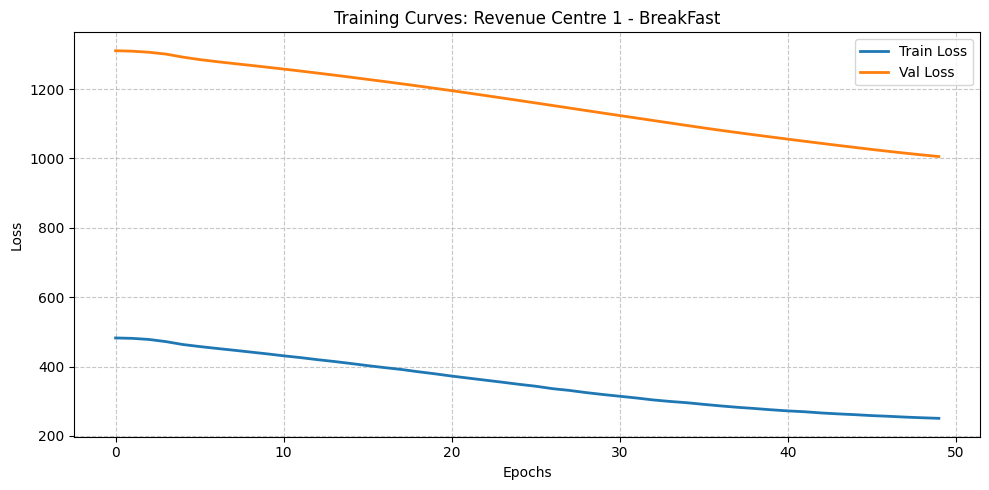

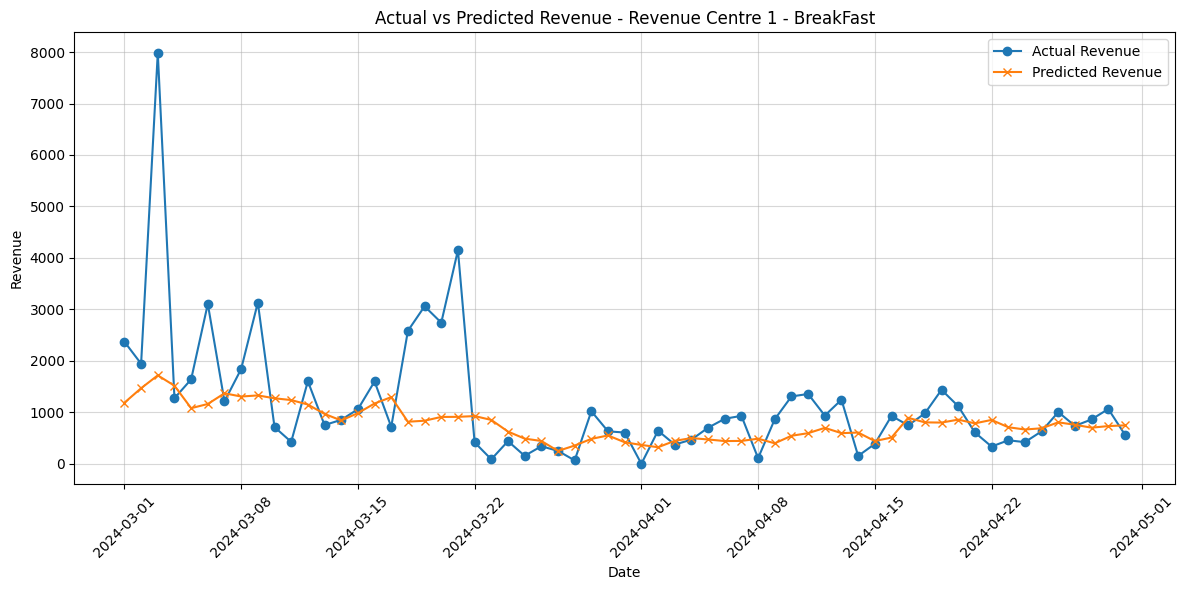

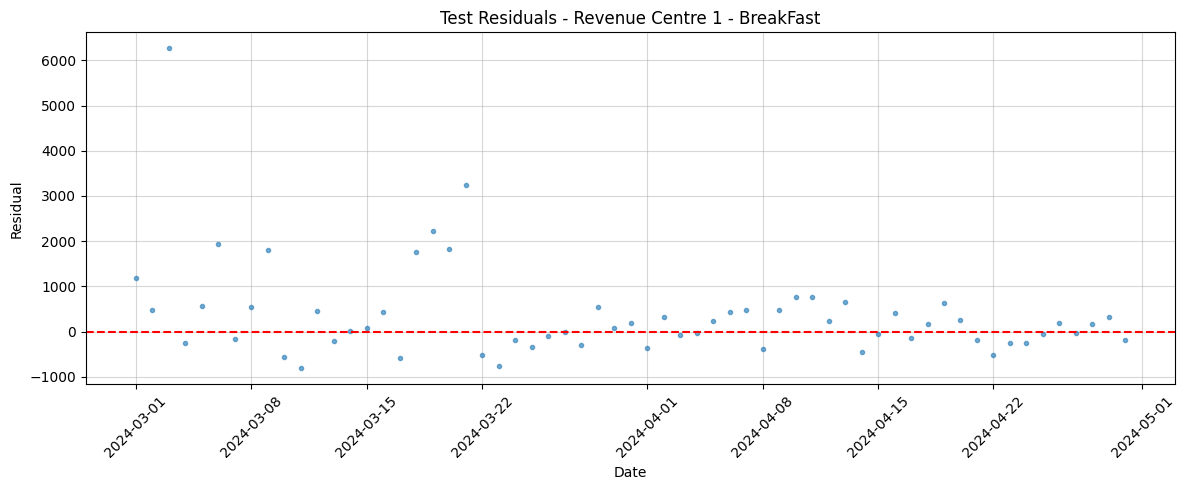

{'Center': 'Revenue Centre 1', 'Meal_Period': 'BreakFast', 'LR': 0.001, 'Filters': 128, 'Alpha': 10.0, 'RMSE': 1130.3181207237226, 'MAE': np.float64(620.4387099731622)}
📊 Training ConvLSTM Model for Revenue Centre 1 - Dinner


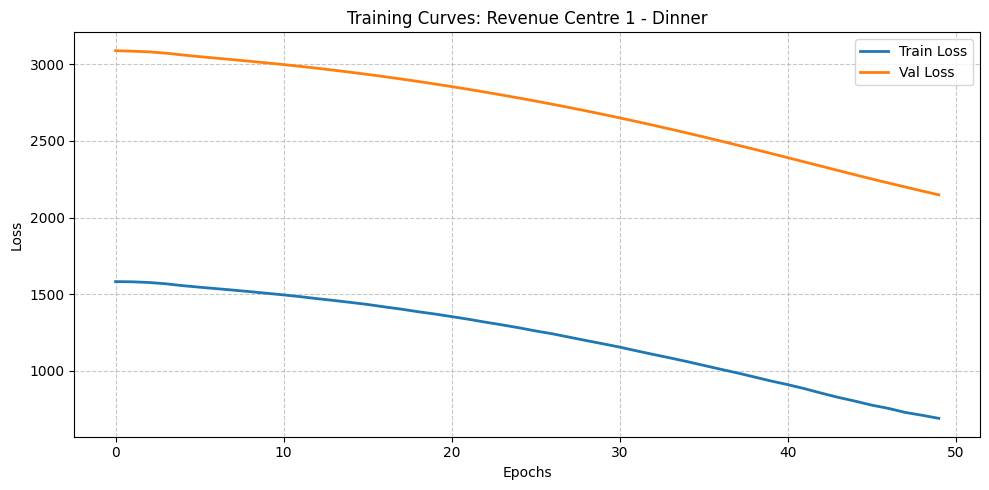

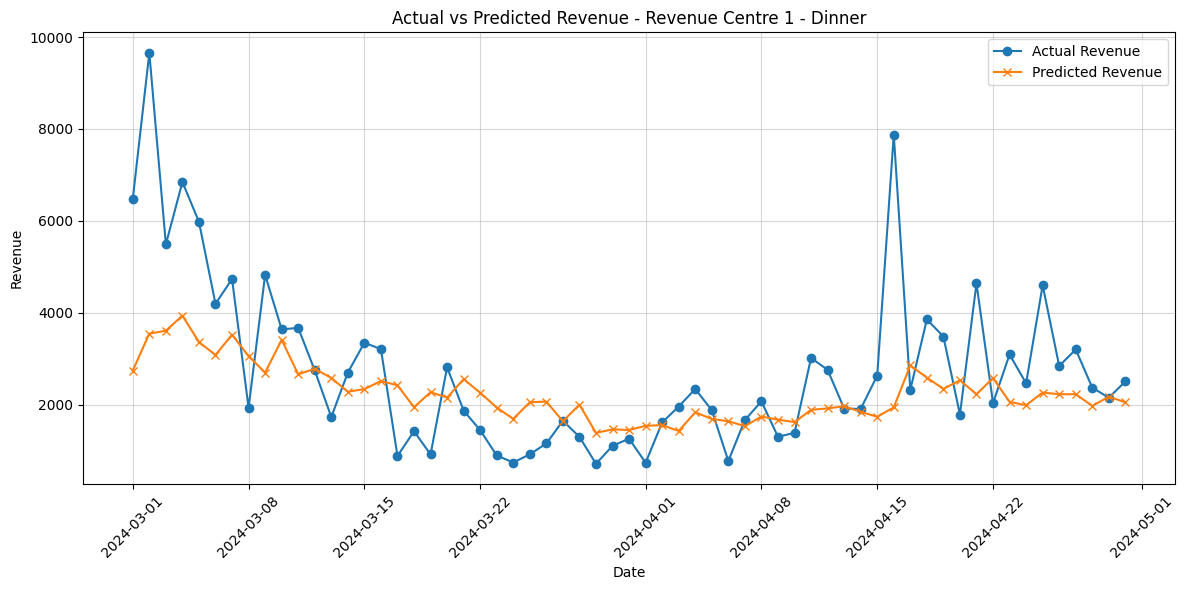

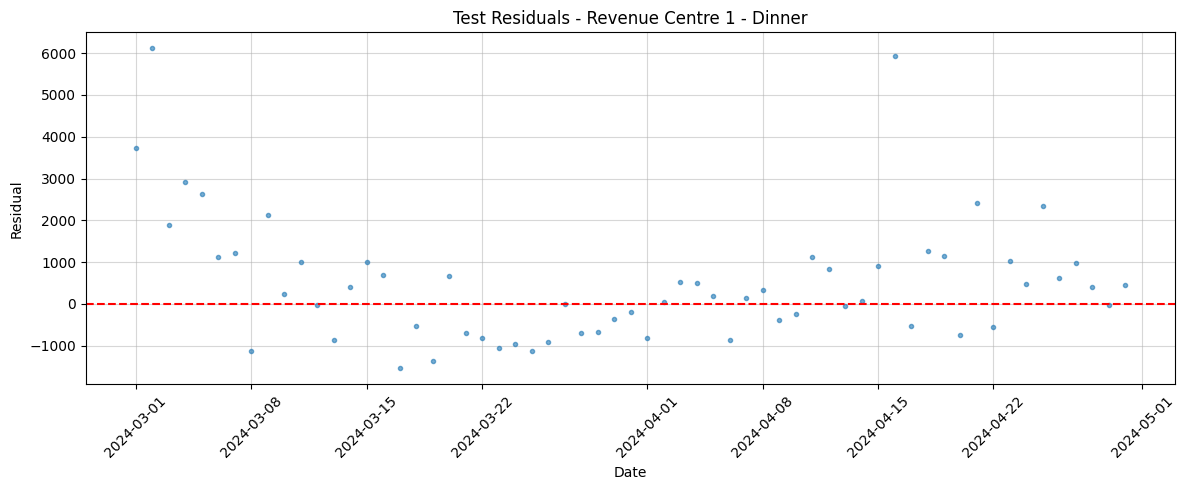

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Dinner', 'LR': 0.001, 'Filters': 128, 'Alpha': 10.0, 'RMSE': 1579.058887778404, 'MAE': np.float64(1057.7880125021834)}
📊 Training ConvLSTM Model for Revenue Centre 1 - Lunch


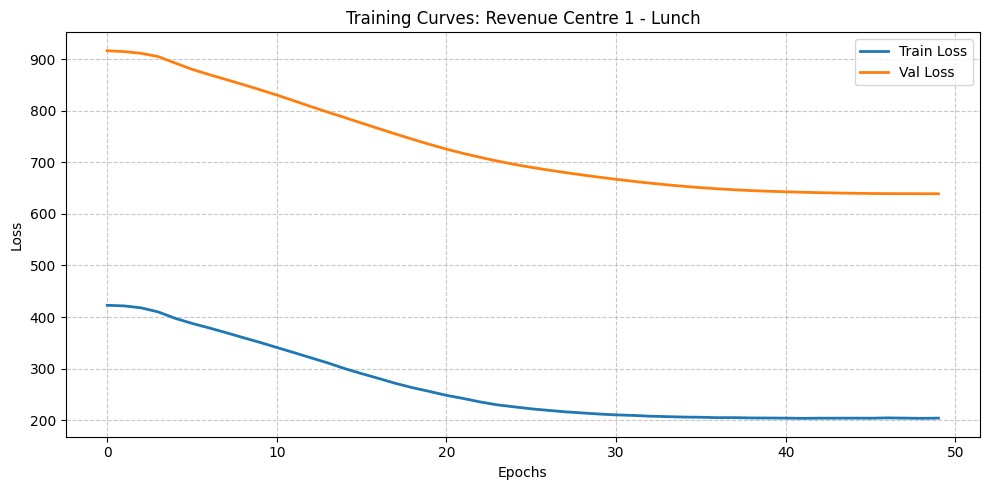

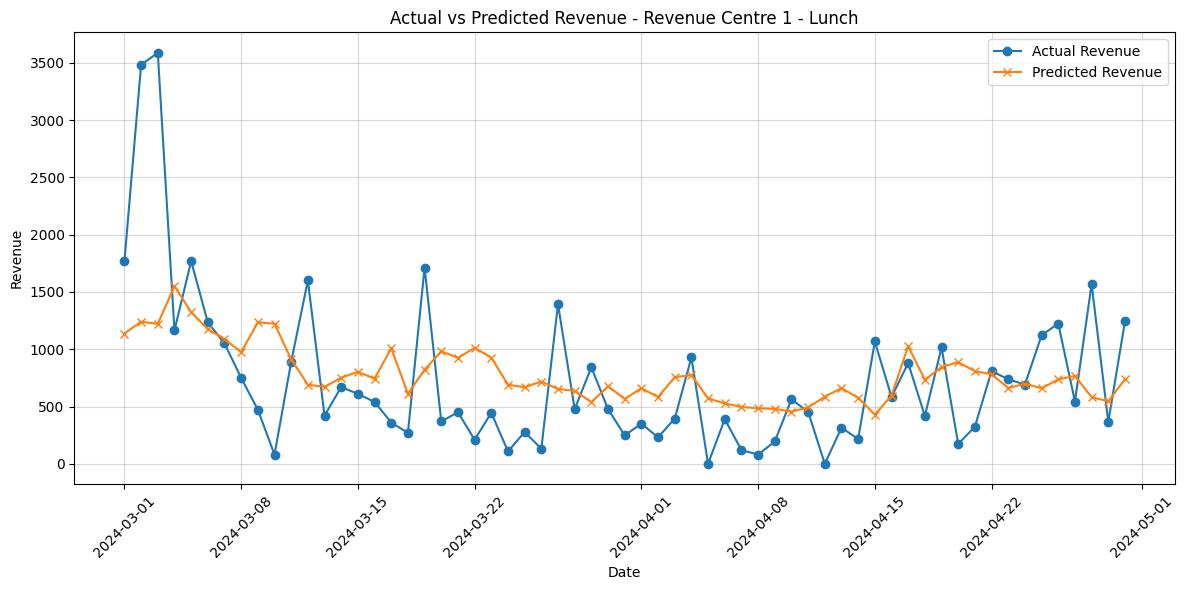

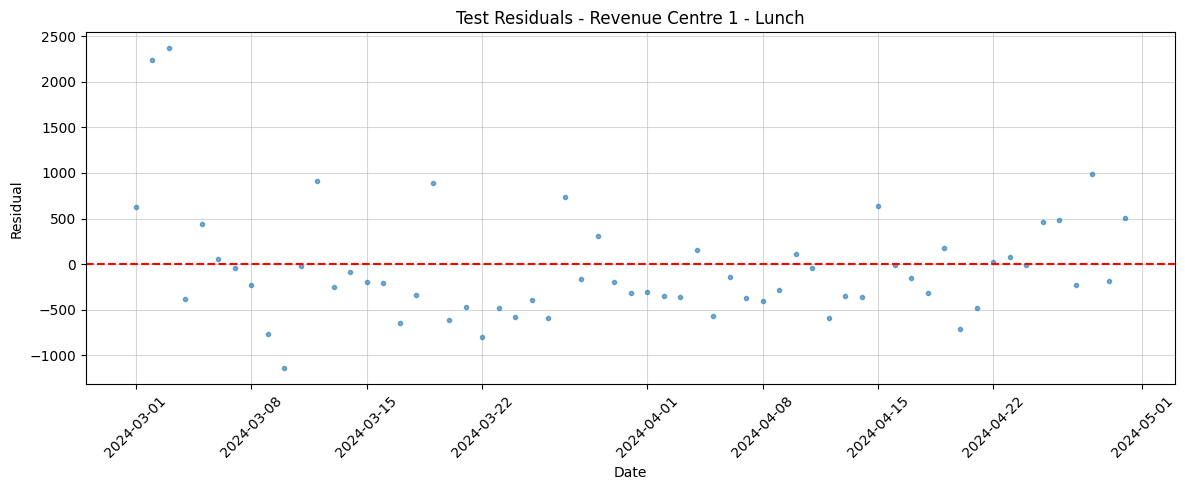

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Lunch', 'LR': 0.001, 'Filters': 128, 'Alpha': 10.0, 'RMSE': 620.7616230860839, 'MAE': np.float64(447.66621751622597)}


In [47]:
# ================== LOAD CENTER AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    for center_id in range(0, 1):  # adjust as needed
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")